# Run RBC Baseline Controller for TX & VT
# 为 TX 和 VT 运行 RBC 基线控制器

This notebook runs a **BasicBatteryRBC controller** for both Texas (TX) and Vermont (VT) scenarios,
本笔记本为德克萨斯州（TX）和佛蒙特州（VT）两个场景各运行一个**基线电池 RBC 控制器**，

compares the performance against no-storage baseline, and generates KPI metrics.
将性能与无储能基线进行对比，并生成 KPI 指标。

- **TX**: Cooling-dominated (August training, September testing)
- **TX**：制冷主导（8 月训练，9 月测试）
- **VT**: Heating-dominated (January training, February testing)
- **VT**：供暖主导（1 月训练，2 月测试）

## 1. Setup Environment and Paths
## 1. 设置环境和路径

In [26]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Find repo root containing 'citylearn/' folder
# 找到包含 'citylearn/' 文件夹的仓库根目录
HERE = Path.cwd()
REPO_DIR = None
for p in [HERE] + list(HERE.parents):
    if (p / 'citylearn').exists():
        REPO_DIR = p
        break

if REPO_DIR is None:
    raise FileNotFoundError('Could not find repo root with citylearn folder')

# Add repo to Python path to use local CityLearn version
# 将仓库添加到 Python 路径，使用本地 CityLearn 版本
sys.path.insert(0, str(REPO_DIR))

# Import CityLearn
# 导入 CityLearn
from citylearn.citylearn import CityLearnEnv
from citylearn.agents.rbc import BasicBatteryRBC

print('✅ CityLearn imported successfully')
print(f'✅ Repo root: {REPO_DIR}')

✅ CityLearn imported successfully
✅ Repo root: /home/yue/EthanZhu/annex96_common_exercise_1


## 2. Define Function to Run RBC Baseline
## 2. 定义运行 RBC 基线的函数

In [27]:
def run_rbc_baseline(climate, repo_dir=REPO_DIR, verbose=True):
    """
    Run BasicBatteryRBC controller for a given climate scenario.
    运行给定气候场景的 BasicBatteryRBC 控制器。

    Parameters:
    -----------
    climate : str
        Climate scenario: 'TX' (Texas) or 'VT' (Vermont)
        气候场景：'TX'（德克萨斯）或 'VT'（佛蒙特）
    repo_dir : Path
        Repository root directory
        仓库根目录
    verbose : bool
        Print progress messages
        打印进度信息

    Returns:
    --------
    dict : Results containing RBC load, baseline load, target, env, and agent
    dict : 包含 RBC 负荷、基线负荷、目标值、环境和智能体的结果
    """

    climate = climate.upper()
    if climate not in ['TX', 'VT']:
        raise ValueError('climate must be TX or VT')

    # Setup dataset paths
    # 设置数据集路径
    dataset_dir = repo_dir / 'data' / 'datasets' / f'annex96_ce1_{climate.lower()}_neighborhood'
    schema_path = dataset_dir / 'schema.json'
    target_path = dataset_dir / 'district_target.csv'

    if not schema_path.exists():
        raise FileNotFoundError(f'Schema not found at {schema_path}')

    if verbose:
        print(f"\n{'='*60}")
        print(f'Running RBC Baseline for {climate}')
        print(f"{'='*60}")
        print(f'Dataset: {dataset_dir}')

    # Create environment
    # 创建环境
    env = CityLearnEnv(
        schema=str(schema_path),
        root_directory=str(dataset_dir),
        central_agent=True
    )

    # Reset and get initial observations
    # 重置并获取初始观测值
    obs, info = env.reset()

    if verbose:
        print(f'Number of buildings: {len(env.buildings)}')
        print(f'Number of time steps: {env.time_steps}')

    # Initialize RBC agent
    # 初始化 RBC 智能体
    agent = BasicBatteryRBC(env)

    if verbose:
        print(f'Agent: {type(agent).__name__}')
        print(f'Running simulation...')

    # Run simulation
    # 运行仿真
    obs, info = env.reset()
    step_count = 0
    while not env.terminated:
        actions = agent.predict(obs)
        obs, reward, terminated, truncated, info = env.step(actions)
        step_count += 1

    if verbose:
        print(f'Simulation completed: {step_count} steps')

    # Extract results
    # 提取结果
    rbc_load = np.array(env.net_electricity_consumption)
    baseline_load = np.array(env.net_electricity_consumption_without_storage)

    # Load district target
    # 加载区域目标负荷
    target_df = pd.read_csv(target_path)
    target = target_df['district_load_target'].values

    if verbose:
        print(f'✅ RBC load shape: {rbc_load.shape}')
        print(f'✅ Baseline load shape: {baseline_load.shape}')
        print(f'✅ Target load shape: {target.shape}')

    return {
        'climate': climate,
        'rbc_load': rbc_load,
        'baseline_load': baseline_load,
        'target': target,
        'env': env,
        'agent': agent,
        'dataset_dir': dataset_dir
    }

## 3. Run RBC for Both TX and VT
## 3. 分别为 TX 和 VT 运行 RBC

In [28]:
# Run for Texas (TX)
# 运行德克萨斯场景
results_tx = run_rbc_baseline('TX', verbose=True)


Running RBC Baseline for TX
Dataset: /home/yue/EthanZhu/annex96_common_exercise_1/data/datasets/annex96_ce1_tx_neighborhood
Number of buildings: 25
Number of time steps: 720
Agent: BasicBatteryRBC
Running simulation...
Simulation completed: 719 steps
✅ RBC load shape: (720,)
✅ Baseline load shape: (720,)
✅ Target load shape: (8760,)


In [29]:
# Run for Vermont (VT)
# 运行佛蒙特场景
results_vt = run_rbc_baseline('VT', verbose=True)


Running RBC Baseline for VT
Dataset: /home/yue/EthanZhu/annex96_common_exercise_1/data/datasets/annex96_ce1_vt_neighborhood
Number of buildings: 25
Number of time steps: 744
Agent: BasicBatteryRBC
Running simulation...
Simulation completed: 743 steps
✅ RBC load shape: (744,)
✅ Baseline load shape: (744,)
✅ Target load shape: (8760,)


## 4. Calculate KPI Metrics
## 4. 计算 KPI 指标

In [30]:
def calculate_kpis(rbc_load, baseline_load, target):
    """
    Calculate key performance indicators for RBC vs baseline.
    计算 RBC 和基线之间的关键性能指标。
    """

    # Align all series to the same length before metric calculation.
    # 在计算指标前先将所有序列对齐到相同长度。
    min_length = min(len(rbc_load), len(baseline_load), len(target))
    rbc_load = np.asarray(rbc_load)[:min_length]
    baseline_load = np.asarray(baseline_load)[:min_length]
    target = np.asarray(target)[:min_length]

    # NMBE: Normalized Mean Bias Error
    # NMBE：归一化平均偏差误差
    nmbe_rbc = np.mean(rbc_load - target) / np.mean(target) * 100
    nmbe_baseline = np.mean(baseline_load - target) / np.mean(target) * 100

    # CV-RMSE: Coefficient of Variation of RMSE
    # CV-RMSE：RMSE 变异系数
    rmse_rbc = np.sqrt(np.mean((rbc_load - target)**2))
    cv_rmse_rbc = rmse_rbc / np.mean(target) * 100

    rmse_baseline = np.sqrt(np.mean((baseline_load - target)**2))
    cv_rmse_baseline = rmse_baseline / np.mean(target) * 100

    # Peak demand
    # 峰值负荷
    peak_rbc = np.max(rbc_load)
    peak_baseline = np.max(baseline_load)
    peak_target = np.max(target)

    # Average load
    # 平均负荷
    avg_rbc = np.mean(rbc_load)
    avg_baseline = np.mean(baseline_load)
    avg_target = np.mean(target)

    return {
        'NMBE_RBC': nmbe_rbc,
        'NMBE_Baseline': nmbe_baseline,
        'CV_RMSE_RBC': cv_rmse_rbc,
        'CV_RMSE_Baseline': cv_rmse_baseline,
        'Peak_RBC': peak_rbc,
        'Peak_Baseline': peak_baseline,
        'Peak_Target': peak_target,
        'Avg_RBC': avg_rbc,
        'Avg_Baseline': avg_baseline,
        'Avg_Target': avg_target
    }

# Calculate KPIs for both scenarios
# 计算两个场景的 KPI
kpis_tx = calculate_kpis(results_tx['rbc_load'], results_tx['baseline_load'], results_tx['target'])
kpis_vt = calculate_kpis(results_vt['rbc_load'], results_vt['baseline_load'], results_vt['target'])

print('\n' + '='*60)
print('TX - Key Performance Indicators')
print('='*60)
for key, value in kpis_tx.items():
    print(f'{key:20s}: {value:10.2f}')

print('\n' + '='*60)
print('VT - Key Performance Indicators')
print('='*60)
for key, value in kpis_vt.items():
    print(f'{key:20s}: {value:10.2f}')


TX - Key Performance Indicators
NMBE_RBC            :        inf
NMBE_Baseline       :        inf
CV_RMSE_RBC         :        inf
CV_RMSE_Baseline    :        inf
Peak_RBC            :     127.42
Peak_Baseline       :      96.19
Peak_Target         :       0.00
Avg_RBC             :      36.98
Avg_Baseline        :      34.94
Avg_Target          :       0.00

VT - Key Performance Indicators
NMBE_RBC            :     103.93
NMBE_Baseline       :     101.11
CV_RMSE_RBC         :     129.09
CV_RMSE_Baseline    :     144.56
Peak_RBC            :     340.24
Peak_Baseline       :     314.16
Peak_Target         :     194.97
Avg_RBC             :     203.03
Avg_Baseline        :     200.23
Avg_Target          :      99.56


## 5. Visualize Results - First Week Comparison
## 5. 可视化结果 - 第一周对比

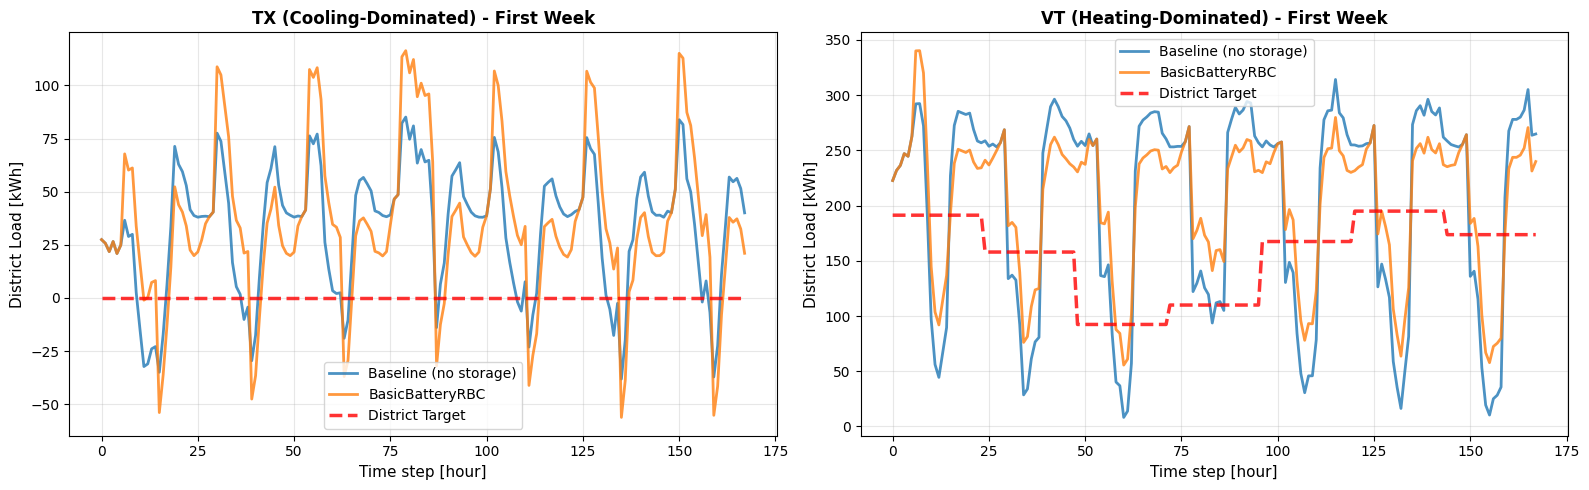

✅ Plot saved: rbc_baseline_comparison_week1.png


In [31]:
# Plot first week comparison for both scenarios
# 为两个场景绘制第一周对比图

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# TX scenario
# TX 场景
week_tx = 24 * 7
hours_tx = np.arange(week_tx)
target_tx = np.asarray(results_tx['target'])[:week_tx]

axes[0].plot(hours_tx, results_tx['baseline_load'][:week_tx], 
             label='Baseline (no storage)', linewidth=2, alpha=0.8)
axes[0].plot(hours_tx, results_tx['rbc_load'][:week_tx], 
             label='BasicBatteryRBC', linewidth=2, alpha=0.8)
axes[0].plot(hours_tx, target_tx, 
             '--', label='District Target', linewidth=2.5, color='red', alpha=0.8)
axes[0].set_xlabel('Time step [hour]', fontsize=11)
axes[0].set_ylabel('District Load [kWh]', fontsize=11)
axes[0].set_title('TX (Cooling-Dominated) - First Week', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# VT scenario
# VT 场景
week_vt = 24 * 7
hours_vt = np.arange(week_vt)
target_vt = np.asarray(results_vt['target'])[:week_vt]

axes[1].plot(hours_vt, results_vt['baseline_load'][:week_vt], 
             label='Baseline (no storage)', linewidth=2, alpha=0.8)
axes[1].plot(hours_vt, results_vt['rbc_load'][:week_vt], 
             label='BasicBatteryRBC', linewidth=2, alpha=0.8)
axes[1].plot(hours_vt, target_vt, 
             '--', label='District Target', linewidth=2.5, color='red', alpha=0.8)
axes[1].set_xlabel('Time step [hour]', fontsize=11)
axes[1].set_ylabel('District Load [kWh]', fontsize=11)
axes[1].set_title('VT (Heating-Dominated) - First Week', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPO_DIR / 'notebooks' / 'rbc_baseline_comparison_week1.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Plot saved: rbc_baseline_comparison_week1.png')

## 6. Visualize Full Simulation Period
## 6. 可视化完整仿真期间

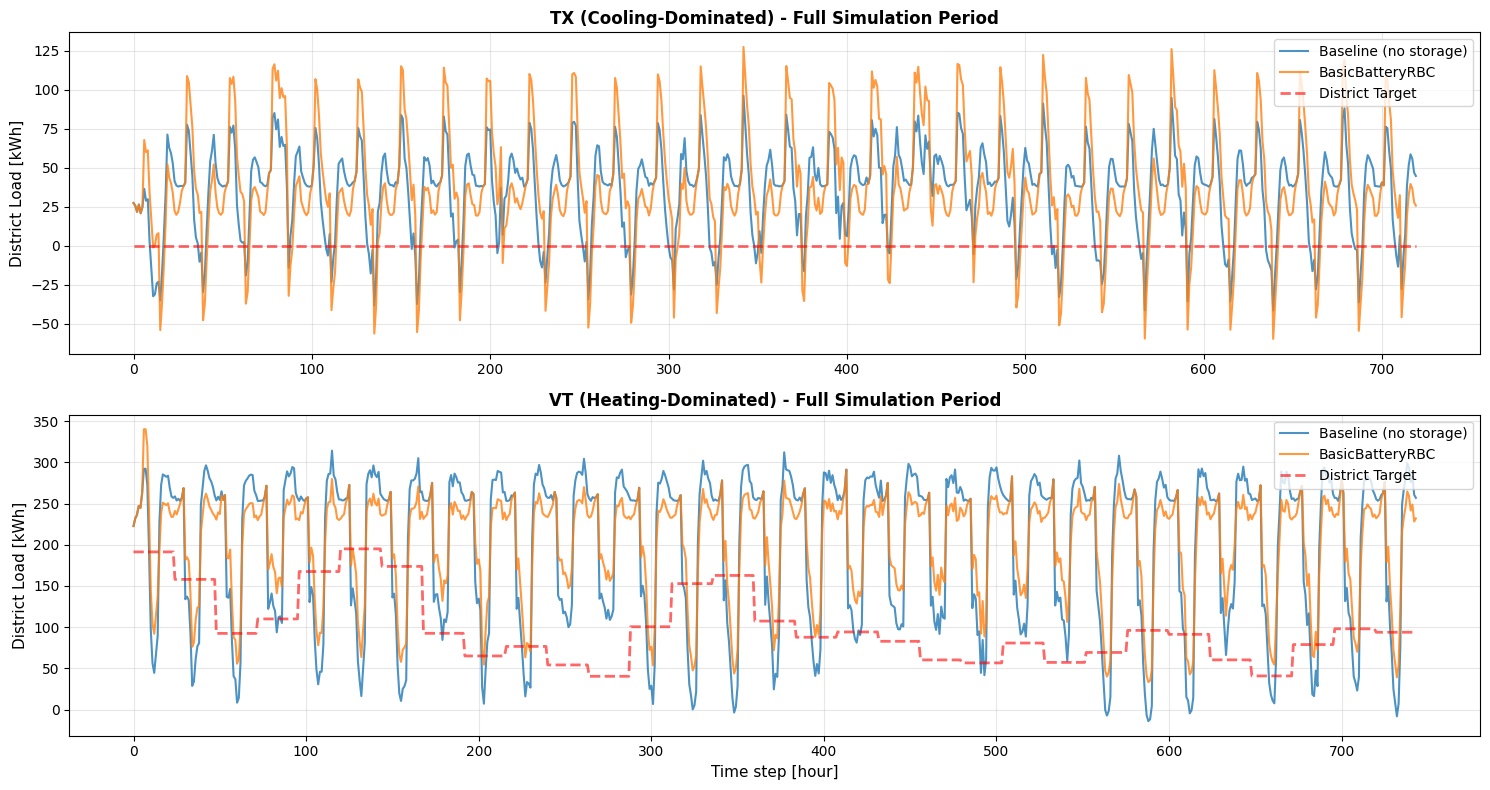

✅ Plot saved: rbc_baseline_comparison_full.png


In [32]:
# Plot entire simulation period
# 绘制整个仿真期间

fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# TX scenario - full period
# TX 场景 - 完整期间
time_steps_tx = np.arange(len(results_tx['rbc_load']))
target_tx = np.asarray(results_tx['target'])[:len(time_steps_tx)]
axes[0].plot(time_steps_tx, results_tx['baseline_load'], 
             label='Baseline (no storage)', linewidth=1.5, alpha=0.8)
axes[0].plot(time_steps_tx, results_tx['rbc_load'], 
             label='BasicBatteryRBC', linewidth=1.5, alpha=0.8)
axes[0].plot(time_steps_tx, target_tx, 
             '--', label='District Target', linewidth=2, color='red', alpha=0.6)
axes[0].set_ylabel('District Load [kWh]', fontsize=11)
axes[0].set_title('TX (Cooling-Dominated) - Full Simulation Period', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10, loc='upper right')
axes[0].grid(True, alpha=0.3)

# VT scenario - full period
# VT 场景 - 完整期间
time_steps_vt = np.arange(len(results_vt['rbc_load']))
target_vt = np.asarray(results_vt['target'])[:len(time_steps_vt)]
axes[1].plot(time_steps_vt, results_vt['baseline_load'], 
             label='Baseline (no storage)', linewidth=1.5, alpha=0.8)
axes[1].plot(time_steps_vt, results_vt['rbc_load'], 
             label='BasicBatteryRBC', linewidth=1.5, alpha=0.8)
axes[1].plot(time_steps_vt, target_vt, 
             '--', label='District Target', linewidth=2, color='red', alpha=0.6)
axes[1].set_xlabel('Time step [hour]', fontsize=11)
axes[1].set_ylabel('District Load [kWh]', fontsize=11)
axes[1].set_title('VT (Heating-Dominated) - Full Simulation Period', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPO_DIR / 'notebooks' / 'rbc_baseline_comparison_full.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Plot saved: rbc_baseline_comparison_full.png')

## 7. Create Summary Table
## 7. 创建汇总表格

In [33]:
# Create comprehensive summary table
# 创建综合汇总表格

summary_data = {
    'Metric': [
        'NMBE RBC (%)',
        'NMBE Baseline (%)',
        'CV-RMSE RBC (%)',
        'CV-RMSE Baseline (%)',
        'Peak Demand RBC (kWh)',
        'Peak Demand Baseline (kWh)',
        'Peak Demand Target (kWh)',
        'Avg Load RBC (kWh)',
        'Avg Load Baseline (kWh)',
        'Avg Load Target (kWh)'
    ],
    'TX': [
        f"{kpis_tx['NMBE_RBC']:.2f}",
        f"{kpis_tx['NMBE_Baseline']:.2f}",
        f"{kpis_tx['CV_RMSE_RBC']:.2f}",
        f"{kpis_tx['CV_RMSE_Baseline']:.2f}",
        f"{kpis_tx['Peak_RBC']:.2f}",
        f"{kpis_tx['Peak_Baseline']:.2f}",
        f"{kpis_tx['Peak_Target']:.2f}",
        f"{kpis_tx['Avg_RBC']:.2f}",
        f"{kpis_tx['Avg_Baseline']:.2f}",
        f"{kpis_tx['Avg_Target']:.2f}"
    ],
    'VT': [
        f"{kpis_vt['NMBE_RBC']:.2f}",
        f"{kpis_vt['NMBE_Baseline']:.2f}",
        f"{kpis_vt['CV_RMSE_RBC']:.2f}",
        f"{kpis_vt['CV_RMSE_Baseline']:.2f}",
        f"{kpis_vt['Peak_RBC']:.2f}",
        f"{kpis_vt['Peak_Baseline']:.2f}",
        f"{kpis_vt['Peak_Target']:.2f}",
        f"{kpis_vt['Avg_RBC']:.2f}",
        f"{kpis_vt['Avg_Baseline']:.2f}",
        f"{kpis_vt['Avg_Target']:.2f}"
    ]
}

summary_df = pd.DataFrame(summary_data)

print('\n' + '='*80)
print('COMPREHENSIVE KPI SUMMARY - TX vs VT')
print('='*80)
print(summary_df.to_string(index=False))
print('='*80)

# Save summary to CSV
# 将汇总保存为 CSV
csv_path = REPO_DIR / 'notebooks' / 'rbc_baseline_kpi_summary.csv'
summary_df.to_csv(csv_path, index=False)
print(f'✅ Summary saved to: {csv_path}')


COMPREHENSIVE KPI SUMMARY - TX vs VT
                    Metric     TX     VT
              NMBE RBC (%)    inf 103.93
         NMBE Baseline (%)    inf 101.11
           CV-RMSE RBC (%)    inf 129.09
      CV-RMSE Baseline (%)    inf 144.56
     Peak Demand RBC (kWh) 127.42 340.24
Peak Demand Baseline (kWh)  96.19 314.16
  Peak Demand Target (kWh)   0.00 194.97
        Avg Load RBC (kWh)  36.98 203.03
   Avg Load Baseline (kWh)  34.94 200.23
     Avg Load Target (kWh)   0.00  99.56
✅ Summary saved to: /home/yue/EthanZhu/annex96_common_exercise_1/notebooks/rbc_baseline_kpi_summary.csv


## 8. Export Detailed Results
## 8. 导出详细结果

In [34]:
# Export hourly load data for both scenarios
# 导出两个场景的逐时负荷数据

# TX detailed results
tx_len = len(results_tx['rbc_load'])
tx_target = np.asarray(results_tx['target'])[:tx_len]
tx_baseline = np.asarray(results_tx['baseline_load'])[:tx_len]
tx_rbc = np.asarray(results_tx['rbc_load'])[:tx_len]

tx_detailed = pd.DataFrame({
    'hour': np.arange(tx_len),
    'baseline_load': tx_baseline,
    'rbc_load': tx_rbc,
    'target_load': tx_target,
    'rbc_diff': tx_rbc - tx_target,
    'baseline_diff': tx_baseline - tx_target
})

tx_path = REPO_DIR / 'notebooks' / 'rbc_baseline_tx_detailed.csv'
tx_detailed.to_csv(tx_path, index=False)
print(f'✅ TX detailed results saved to: {tx_path}')
print(f'   Rows: {len(tx_detailed)}')

# VT detailed results
vt_len = len(results_vt['rbc_load'])
vt_target = np.asarray(results_vt['target'])[:vt_len]
vt_baseline = np.asarray(results_vt['baseline_load'])[:vt_len]
vt_rbc = np.asarray(results_vt['rbc_load'])[:vt_len]

vt_detailed = pd.DataFrame({
    'hour': np.arange(vt_len),
    'baseline_load': vt_baseline,
    'rbc_load': vt_rbc,
    'target_load': vt_target,
    'rbc_diff': vt_rbc - vt_target,
    'baseline_diff': vt_baseline - vt_target
})

vt_path = REPO_DIR / 'notebooks' / 'rbc_baseline_vt_detailed.csv'
vt_detailed.to_csv(vt_path, index=False)
print(f'✅ VT detailed results saved to: {vt_path}')
print(f'   Rows: {len(vt_detailed)}')

✅ TX detailed results saved to: /home/yue/EthanZhu/annex96_common_exercise_1/notebooks/rbc_baseline_tx_detailed.csv
   Rows: 720
✅ VT detailed results saved to: /home/yue/EthanZhu/annex96_common_exercise_1/notebooks/rbc_baseline_vt_detailed.csv
   Rows: 744


## 9. Performance Summary
## 9. 性能总结

In [35]:
print('\n' + '='*80)
print('BASELINE RBC CONTROLLER - COMPLETION SUMMARY')
print('='*80)

print('\n📊 GENERATED OUTPUTS:')
print('  1. Plots:')
print('     - rbc_baseline_comparison_week1.png  (First week comparison)')
print('     - rbc_baseline_comparison_full.png   (Full simulation period)')
print('  2. Data Files:')
print('     - rbc_baseline_kpi_summary.csv       (KPI metrics)')
print('     - rbc_baseline_tx_detailed.csv       (TX hourly data)')
print('     - rbc_baseline_vt_detailed.csv       (VT hourly data)')

print('\n📈 KEY FINDINGS:')
print(f'  TX (Cooling-Dominated):')
print(f'    - NMBE (RBC vs Target): {kpis_tx["NMBE_RBC"]:.2f}%')
print(f'    - CV-RMSE: {kpis_tx["CV_RMSE_RBC"]:.2f}%')
print(f'    - Peak Load (RBC): {kpis_tx["Peak_RBC"]:.2f} kWh')

print(f'  VT (Heating-Dominated):')
print(f'    - NMBE (RBC vs Target): {kpis_vt["NMBE_RBC"]:.2f}%')
print(f'    - CV-RMSE: {kpis_vt["CV_RMSE_RBC"]:.2f}%')
print(f'    - Peak Load (RBC): {kpis_vt["Peak_RBC"]:.2f} kWh')

print('\n✅ All results have been generated and saved!')
print('='*80)


BASELINE RBC CONTROLLER - COMPLETION SUMMARY

📊 GENERATED OUTPUTS:
  1. Plots:
     - rbc_baseline_comparison_week1.png  (First week comparison)
     - rbc_baseline_comparison_full.png   (Full simulation period)
  2. Data Files:
     - rbc_baseline_kpi_summary.csv       (KPI metrics)
     - rbc_baseline_tx_detailed.csv       (TX hourly data)
     - rbc_baseline_vt_detailed.csv       (VT hourly data)

📈 KEY FINDINGS:
  TX (Cooling-Dominated):
    - NMBE (RBC vs Target): inf%
    - CV-RMSE: inf%
    - Peak Load (RBC): 127.42 kWh
  VT (Heating-Dominated):
    - NMBE (RBC vs Target): 103.93%
    - CV-RMSE: 129.09%
    - Peak Load (RBC): 340.24 kWh

✅ All results have been generated and saved!
